# How Neural Networks Learn from Experience
**Author:** Geoffrey E. Hinton (1992) — *Scientific American*

# https://www.cs.toronto.edu/~hinton/absps/sciam2.pdf

## Abstract
This paper explains how artificial neural networks, modeled on simplified idealizations of biological neurons, can learn internal representations of complex information through weight adjustment. It focuses primarily on the back-propagation algorithm, the dominant supervised learning procedure at the time, and situates it alongside unsupervised alternatives (principal-components learning, competitive learning) and biologically motivated coding schemes (population codes). The paper argues that these procedures, despite differing mechanisms, share a common goal: discovering economical, information-preserving representations of input data by iteratively adjusting connection weights.

## Problems
- **Representation learning without explicit instruction**: Biological brains learn to process complex sensory information (speech, faces, language) without being given direct descriptions of what internal representations to form.
- **Credit assignment problem**: For multilayer networks, no direct target exists for hidden units; it is unclear how to adjust weights on connections that do not directly touch the output error.
- **Computational inefficiency of naive approaches**: Estimating the effect of each weight on error by individually perturbing it is computationally intractable for networks with many weights.
- **Biological plausibility**: The back-propagation algorithm, though mathematically effective, requires signals to travel backward through the same connections used for forward propagation, which has no clear anatomical analog.
- **Scalability**: Learning time grows faster than network size, since larger networks require both more computation per example and more training examples.
- **Absence of a teacher in most learning**: Humans learn without labeled training data, motivating the need for unsupervised procedures.

## Proposed Solutions
1. **Back-Propagation Algorithm** (Werbos, 1974; popularized by Rumelhart, Hinton, and Williams, 1986): A supervised procedure that computes error derivatives efficiently by propagating an error signal backward from the output layer to earlier layers.
2. **Unsupervised learning procedures** that do not require a teacher:
   - **Principal-components learning**: extracts shared variation across correlated inputs into a compact code.
   - **Competitive learning**: assigns clusters of similar input patterns to individual hidden units via a "winner-take-all" mechanism, optionally extended by Kohonen's topological neighborhood adaptation.
3. **Population coding**: A biologically inspired representation scheme in which information is distributed across a population of units rather than localized in single neurons, improving robustness to unit loss.
4. **Hierarchical structural checking (Ballard's technique)**: Uses redundancy between population codes of different object parts (e.g., nose and mouth) to verify structural consistency (e.g., that they form a valid face).

## Purpose
The central aim is to explain, at a conceptual and mathematical level, how artificial neural networks can autonomously discover useful internal representations from data through weight modification, and to evaluate the extent to which such computational models illuminate biological learning mechanisms in the brain.

## Methodology
- **Network architecture**: Standard three-layer feedforward network consisting of input, hidden, and output units, fully connected between adjacent layers.
- **Unit computation**: Each unit computes a total weighted input and transforms it via a nonlinear (commonly sigmoid) input-output function:
$$
x_j = \sum_i y_i w_{ij}, \qquad y_j = \frac{1}{1+e^{-x_j}}
$$
- **Error definition**: Sum-of-squares error between actual and desired output activities:
$$
\mathcal{E} = \frac{1}{2}\sum_j (y_j - d_j)^2
$$
- **Back-propagation derivation** (four-step procedure):
  1. Compute error derivative at output units:
$$
EA_j = \frac{\partial \mathcal{E}}{\partial y_j} = y_j - d_j
$$
  2. Convert to input-sensitivity term:
$$
EI_j = \frac{\partial \mathcal{E}}{\partial x_j} = EA_j\, y_j(1-y_j)
$$
  3. Compute weight-error derivative:
$$
EW_{ij} = \frac{\partial \mathcal{E}}{\partial w_{ij}} = EI_j\, y_i
$$
  4. Propagate error backward to prior layer:
$$
EA_i = \sum_j EI_j\, w_{ij}
$$
- **Training procedure**: Present labeled examples, compute forward activations, compute error, back-propagate derivatives, and adjust weights proportionally to $EW$ to reduce error; repeat across the training set until acceptable accuracy is reached.
- **Illustrative application**: A network with 256 input units (image sensors), 9 hidden units, and 10 output units trained to classify handwritten digits, demonstrating how hidden units form internal representations distinguishing digit classes.
- **Unsupervised methods framework**: Formulated as minimization of a combined "code cost" (bits required to describe hidden unit activities) and "reconstruction cost" (bits required to describe misfit between input and its reconstruction from hidden activity).
- **Neuroscience comparisons**: Cited studies (Andersen and Zipser; Sparks; Young and Yamane) comparing back-propagation-trained hidden unit responses and population coding behavior to empirical recordings from monkey visual and motor cortex.

## Results
- Back-propagation successfully trains networks to perform tasks such as handwritten digit recognition, currency exchange rate prediction, chemical process yield optimization, precancerous cell identification in Pap smears, and telescope mirror distortion correction.
- In digit-recognition experiments, hidden units developed structured, interpretable weight patterns (visualized as excitatory/inhibitory regions) that discriminated between digit classes.
- Back-propagation-trained hidden units in models of visual cortex closely resembled response properties of real neurons converting retinal input into higher visual area representations.
- Despite frequent convergence to locally (rather than globally) optimal weight solutions, back-propagation still achieved strong task performance, challenging the assumption that global optimality is necessary for effective learning.
- Unsupervised principal-components and competitive learning algorithms produced compact, low-cost encodings (e.g., representing ellipse images using five parameters instead of pixel coordinates) while preserving reconstructive accuracy.
- Population coding demonstrated resilience to unit loss and provided a plausible account of how the brain encodes continuous multiparameter variables (e.g., eye movement direction, facial features).
- Ballard's structural-consistency technique successfully distinguished correctly configured face parts from randomly positioned ones using population code redundancy.

## Conclusions
- Back-propagation, despite biological implausibility regarding reverse signal transmission, remains a powerful and widely applicable tool for training multilayer neural networks and for probing hypotheses about representation formation in the cortex.
- Unsupervised learning procedures, which minimize a combination of code and reconstruction costs, offer biologically plausible alternatives that do not require a teacher, addressing key limitations of supervised approaches.
- Population coding provides a biologically consistent, robust mechanism for representing continuous, multiparameter information distributed across neuron populations.
- Hierarchical use of population codes, combined with consistency-checking mechanisms, suggests a promising direction for extracting increasingly efficient and structured internal representations from sensory input.
- While no single learning procedure discussed is confirmed as the brain's actual mechanism, continued convergence of computational and empirical neuroscience findings is expected to clarify which representations and learning rules are biologically employed.

# Mathematical and Statistical Content in the Paper

The paper contains relatively little formal mathematics in the main text, with the core equations concentrated in the boxed section "The Back-Propagation Algorithm." Below is each mathematical concept, explained simply, in the order it appears.

## 1. Total Weighted Input

$$
x_j = \sum_i y_i w_{ij}
$$

**Meaning:** Each unit (artificial neuron) receives signals from other units. This equation adds up all incoming signals after scaling each one by its connection strength (weight). $y_i$ is the activity of a sending unit, $w_{ij}$ is the weight on the connection to unit $j$. This sum is the "raw input" a unit receives before deciding how strongly to respond.

## 2. Sigmoid Input-Output Function

$$
y_j = \frac{1}{1+e^{-x_j}}
$$

**Meaning:** This converts the raw summed input $x_j$ into an output activity between 0 and 1. It is an S-shaped curve: very negative inputs produce outputs near 0, very positive inputs produce outputs near 1, and moderate inputs produce a smooth graded response. This nonlinearity allows networks to represent complex, non-linear relationships.

## 3. Error Function (Sum of Squared Errors)

$$
\mathcal{E} = \frac{1}{2}\sum_j (y_j - d_j)^2
$$

**Meaning:** This measures how wrong the network's output is. $y_j$ is the actual output of unit $j$, and $d_j$ is the desired (target) output. The differences are squared (so errors in either direction count as positive) and summed across all output units. The $\frac{1}{2}$ is included purely to simplify the derivative later. This is a standard statistical loss function used in regression-style fitting.

## 4. Back-Propagation: Step 1 — Output Error Derivative

$$
EA_j = \frac{\partial \mathcal{E}}{\partial y_j} = y_j - d_j
$$

**Meaning:** This derivative tells you how much the total error would change if the activity of output unit $j$ changed slightly. For output units, this simplifies to just the difference between actual and desired output. It answers: "Is this unit's output too high or too low, and by how much?"

## 5. Back-Propagation: Step 2 — Converting to Input Sensitivity

$$
EI_j = \frac{\partial \mathcal{E}}{\partial x_j} = EA_j \cdot y_j(1-y_j)
$$

**Meaning:** This uses the chain rule from calculus to convert "how error depends on output activity" into "how error depends on the unit's raw input." The term $y_j(1-y_j)$ is the derivative of the sigmoid function itself — a mathematical fact about how steeply the S-curve is sloped at the current output value. This step translates blame at the output level into blame at the input level.

## 6. Back-Propagation: Step 3 — Weight Error Derivative

$$
EW_{ij} = \frac{\partial \mathcal{E}}{\partial w_{ij}} = EI_j \cdot y_i
$$

**Meaning:** This tells you how much the error would change if a specific weight $w_{ij}$ changed slightly. It is the input-sensitivity term from Step 2 multiplied by the activity of the sending unit $y_i$. This is the actual quantity used to update each weight: weights are nudged in the direction that reduces error.

## 7. Back-Propagation: Step 4 — Propagating Error to the Previous Layer

$$
EA_i = \frac{\partial \mathcal{E}}{\partial y_i} = \sum_j EI_j \, w_{ij}
$$

**Meaning:** This is the key recursive step that gives the algorithm its name. Since hidden units have no direct "desired output," their error contribution must be inferred indirectly. This equation sums the influence of a hidden unit across every output unit it connects to, weighted by connection strength. Repeating Steps 2–4 layer by layer allows error information to flow backward through the network, even though activity itself only flowed forward during the original computation.

**Overall role in the paper:** These four equations together define a systematic method for computing, for every weight in a multilayer network, exactly how that weight should be adjusted to reduce overall error — without needing to test each weight individually by trial and error.

## 8. Dimensionality Reduction (Ellipse Example)

No explicit formula is given, but the paper describes a **parameter-counting argument**: an ellipse can be fully described by 5 numbers (orientation, vertical position, horizontal position, length, width), compared to describing every pixel individually. This illustrates the general statistical idea of **compact representation** — expressing high-dimensional raw data (many pixels) using a much smaller number of meaningful underlying parameters, similar in spirit to dimensionality-reduction techniques.

## 9. Code Cost and Reconstruction Cost (Conceptual Optimization)

**Meaning (described qualitatively, not with explicit formulas):** Unsupervised learning methods are framed as minimizing the sum of two quantities:
- **Code cost:** the number of bits needed to describe the hidden units' activity (a measure of representational compactness).
- **Reconstruction cost:** the number of bits needed to describe the mismatch between the original input and what can be reconstructed from the hidden code, computed as proportional to the **squared difference** between the raw input and its reconstruction (an implicit least-squares criterion, structurally similar to the output error function above).

This is a general information-theoretic optimization principle: find a representation that is both economical (small code cost) and accurate (small reconstruction cost).

## 10. Population Coding as a Statistical Averaging Process

**Meaning (conceptual, not equation-based):** A population code represents a parameter (e.g., eye movement direction) as a weighted "bump" of activity spread across many units, where the encoded value corresponds to something like a **weighted average** (center of mass) of the population's activity pattern. This is statistically robust because losing a few units barely shifts the average, unlike a single dedicated unit whose loss would eliminate the encoded information entirely.

---

**Summary of mathematical role in the paper:** The core rigorous mathematics is the four-step back-propagation derivation, a direct application of the **chain rule of calculus** to a layered computational graph, used to perform **gradient-based error minimization**. The remaining mathematical ideas (dimensionality reduction, code/reconstruction cost minimization, and population averaging) are described conceptually and support the broader statistical theme of the paper: learning is framed throughout as an optimization problem — minimizing an error or cost function by iteratively adjusting parameters (weights).

# Key Problems, Limitations, and Proposed Solutions

| # | Problem / Research Gap | Limitation in Prior Work / Understanding | Proposed Solution in the Paper |
|---|---|---|---|
| 1 | Brain learns complex sensory representations (speech, faces, scenes) without explicit instructions describing what to represent | No existing theory fully explained how the brain constructs internal representations from raw, unlabeled sensory input | Model learning as a process of adjusting synaptic weights in artificial neural networks, using idealized neuron units to test competing hypotheses about representation formation |
| 2 | Credit assignment in multilayer networks: hidden units have no directly specified "correct" output | Without a defined target for hidden units, it was unclear how to determine the direction and magnitude of weight changes needed to reduce output error | Back-propagation algorithm: recursively compute error derivatives for hidden units by propagating output error backward through the network using the chain rule |
| 3 | Computing error derivatives via individual weight perturbation is computationally inefficient | Perturbing one weight at a time to observe its effect on error requires a separate computation per weight, making learning infeasible in networks with many weights | Back-propagation computes all weight derivatives ($EW$) in a single backward pass using EA and EI intermediate quantities, avoiding per-weight perturbation |
| 4 | Non-linear units complicate error derivative calculation | Simple weight-based derivative propagation (as in linear networks) does not directly generalize to units with non-linear (sigmoid) input-output functions | Introduce an intermediate step converting the activity error derivative (EA) into an input error derivative (EI) via multiplication by the sigmoid's local slope, $y_j(1-y_j)$ |
| 5 | Back-propagation's biological plausibility is questionable | The algorithm requires error information to travel backward through the same connections used for forward signal propagation, which lacks a clear anatomical basis in real neurons | Paper does not fully resolve this gap but notes the brain contains many backward pathways between layers, suggesting alternative biological mechanisms could convey comparable information; also introduces biologically motivated alternatives (unsupervised learning, population coding) |
| 6 | Back-propagation requires a "teacher" supplying desired outputs for every training example | Most human learning occurs without externally provided target outputs, unlike back-propagation's supervised training requirement | Present unsupervised learning procedures (principal-components learning, competitive learning) that adjust weights based on input statistics alone, without requiring predefined desired outputs |
| 7 | Learning time scales poorly as network size increases | Larger networks require proportionally more computation per training example and also require more training examples and weight updates, causing learning time to grow faster than network size | Propose hierarchical, layer-by-layer unsupervised pretraining, where each layer learns an improved representation independently, reducing dependence on later-layer weights and potentially accelerating overall learning |
| 8 | Local vs. global optimization: gradient-based learning may converge to locally, not globally, optimal weight configurations | It was widely believed that only algorithms guaranteed to reach a global optimum could be practically useful, creating skepticism toward gradient-descent methods | Empirically demonstrate that back-propagation achieves strong task performance even without global optimality guarantees, showing local convergence is often sufficient in practice |
| 9 | Excessive representational redundancy elimination makes networks fragile to unit loss | Many code-cost minimization methods produce representations vulnerable to failure of individual hidden units, unlike biological neural systems | Adopt population coding, in which information is distributed across many units as an activity "bump," providing robustness to the loss of individual neurons |
| 10 | Verifying structural consistency between represented object parts (e.g., ensuring recognized features correctly form a coherent whole, such as a face) | Standard population coding methods lack a mechanism to check whether independently encoded parts are spatially or structurally consistent with one another | Introduce Ballard's technique, using redundancy in population codes so consistent part relationships reinforce a combined representation, while inconsistent relationships prevent bump formation, effectively performing implicit structural verification |

In [1]:
# =============================================================================
# EDUCATIONAL PYTORCH REPLICATION
# Paper: "How Neural Networks Learn from Experience" (Geoffrey E. Hinton, 1992)
# -----------------------------------------------------------------------------
# The paper describes the classic 3-LAYER FEEDFORWARD NETWORK (input -> hidden
# -> output), where every unit computes:
#     x_j = sum_i( y_i * w_ij )        <- total weighted input (Eq. 1)
#     y_j = 1 / (1 + e^-x_j)           <- sigmoid activation (Eq. 2)
# and is trained with the BACK-PROPAGATION ALGORITHM to minimize the
# sum-of-squared-errors loss:
#     E = 1/2 * sum_j( y_j - d_j )^2   <- error function (Eq. 3)
# The four back-prop steps (EA, EI, EW, and error-propagation-to-previous-
# layer) are exactly what PyTorch's autograd computes automatically when we
# call loss.backward() -- we annotate the code below to show where each
# paper equation is happening "under the hood".
#
# NOTE ON FAITHFULNESS: This paper has only ONE loss term (squared error) and
# NO auxiliary/pretraining objectives (unlike modern multi-task papers), so
# Panel B below decomposes that single squared-error loss into its PER-CLASS
# (per output unit) components, since the paper explicitly discusses how each
# output unit contributes its own squared error term to the total.
# =============================================================================

import io
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from datasets import load_dataset
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, Image as IPImage

# -----------------------------------------------------------------------------
# GLOBAL WHITE-THEME SETTINGS (applied everywhere, enforced again per-axis)
# -----------------------------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.titlecolor": "black",
    "legend.labelcolor": "black",
    "grid.color": "lightgrey",
})

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]
NUM_CLASSES = len(CLASS_NAMES)

In [ ]:
# =============================================================================
# 1. DATASET PREPARATION (HuggingFace CIFAR-10, mandatory source)
# =============================================================================

# Load CIFAR-10 exclusively from HuggingFace (never torchvision.datasets)
ds = load_dataset("uoft-cs/cifar10")

# Transform pipeline for TRAINING split (with light augmentation)
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

# Transform pipeline for TEST split (no augmentation)
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])


class HFCifar10Dataset(Dataset):
    """
    Wraps a HuggingFace CIFAR-10 split into a standard PyTorch Dataset.
    Each item is read as a PIL image from the 'img' field, converted to RGB,
    transformed, and paired with its integer label from the 'label' field.
    """
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        sample = self.hf_split[idx]
        image = sample["img"]
        if image.mode != "RGB":
            image = image.convert("RGB")
        image_tensor = self.transform(image)
        label = sample["label"]
        return image_tensor, label


# Wrap the HuggingFace train/test splits
train_dataset_full = HFCifar10Dataset(ds["train"], train_transform)
test_dataset_full = HFCifar10Dataset(ds["test"], test_transform)

# Use only a small subset for this educational, 5-epoch demo
train_dataset = Subset(train_dataset_full, list(range(2000)))
test_dataset = Subset(test_dataset_full, list(range(400)))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

# --- Sanity check ---
sample_images, sample_labels = next(iter(train_loader))
print("===== DATASET SANITY CHECK =====")
print(f"Number of training samples : {len(train_dataset)}")
print(f"Number of test samples     : {len(test_dataset)}")
print(f"Shape of one batch of images: {sample_images.shape}")
print(f"Label range                : {sample_labels.min().item()} - {sample_labels.max().item()}")
print(f"First 8 class names in batch: {[CLASS_NAMES[l] for l in sample_labels[:8].tolist()]}")
print("=================================")

In [3]:
# =============================================================================
# 2. MODEL DEFINITION
# -----------------------------------------------------------------------------
# Faithful to the paper: a 3-LAYER fully-connected network
#   INPUT layer  -> flattened pixels (raw sensory information, per the paper)
#   HIDDEN layer -> sigmoid units that "construct their own representations"
#   OUTPUT layer -> sigmoid units, one per class (paper: "high activity in
#                   the appropriate output unit and low activity in others")
# =============================================================================

INPUT_DIM = 3 * 64 * 64   # flattened RGB 64x64 image, as in the paper's
                           # "array of sensors" input layer
HIDDEN_DIM = 256          # number of hidden units (paper used 9 for its
                           # digit example; we scale up for a richer task)


class HintonThreeLayerNet(nn.Module):
    """
    Direct implementation of the paper's 3-layer network:
        x_j = sum_i(y_i * w_ij)          -> nn.Linear does this weighted sum
        y_j = sigmoid(x_j)               -> nn.Sigmoid is the activation
    Both hidden and output layers use sigmoid units, exactly as described.
    """
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()
        # Input -> Hidden connections (weights w_ij in the paper's notation)
        self.hidden_layer = nn.Linear(input_dim, hidden_dim)
        self.hidden_activation = nn.Sigmoid()
        # Hidden -> Output connections
        self.output_layer = nn.Linear(hidden_dim, num_classes)
        self.output_activation = nn.Sigmoid()

    def forward(self, x):
        x = x.view(x.size(0), -1)              # flatten image into input units
        hidden_input = self.hidden_layer(x)     # x_j = sum_i(y_i * w_ij)
        hidden_activity = self.hidden_activation(hidden_input)  # y_j = sigmoid(x_j)
        output_input = self.output_layer(hidden_activity)
        output_activity = self.output_activation(output_input)
        return output_activity                  # final y_j for each output unit


model = HintonThreeLayerNet(INPUT_DIM, HIDDEN_DIM, NUM_CLASSES).to(DEVICE)

# -----------------------------------------------------------------------------
# LOSS: exactly the paper's sum-of-squared-errors, E = 1/2 * sum(y_j - d_j)^2
# We build one-hot "desired activity" vectors d_j (1 for correct class,
# 0 otherwise) to match the paper's supervised training procedure.
# -----------------------------------------------------------------------------
criterion = nn.MSELoss(reduction="sum")  # matches 1/2 * sum((y-d)^2) up to the constant

# -----------------------------------------------------------------------------
# OPTIMIZER: plain stochastic gradient descent.
# The paper: "we need to change each weight by an amount that is proportional
# to the rate at which the error changes as the weight is changed" (EW).
# PyTorch's autograd computes EA -> EI -> EW -> EA(previous layer) for us
# automatically inside loss.backward() -- this IS the back-propagation
# algorithm from the paper's boxed derivation.
# -----------------------------------------------------------------------------
optimizer = optim.SGD(model.parameters(), lr=0.05)

total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

In [4]:
# =============================================================================
# 3. TRAINING LOOP (5 epochs) + VALIDATION
# =============================================================================
NUM_EPOCHS = 5

train_loss_history = []
val_loss_history = []
train_acc_history = []
val_acc_history = []
per_class_acc_per_epoch = []          # for Panel F heatmap: shape (epochs, classes)
per_class_squared_error_per_epoch = []  # for Panel B: shape (epochs, classes)


def one_hot(labels, num_classes):
    """Convert integer labels into the paper's 'desired output' vectors d_j."""
    return torch.eye(num_classes, device=labels.device)[labels]


def run_epoch(loader, train_mode: bool):
    """
    Runs one full pass over `loader`.
    If train_mode=True, performs the forward pass, computes the squared-error
    loss (paper Eq. 3), back-propagates (loss.backward()), and updates
    weights (optimizer.step()) -- i.e. the full back-propagation procedure.
    If train_mode=False, only evaluates (no weight updates).
    Returns average loss, accuracy, per-class accuracy, and per-class
    average squared error for this epoch.
    """
    model.train() if train_mode else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    class_correct = np.zeros(NUM_CLASSES)
    class_total = np.zeros(NUM_CLASSES)
    class_sq_error = np.zeros(NUM_CLASSES)

    context = torch.enable_grad() if train_mode else torch.no_grad()
    with context:
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            desired = one_hot(labels, NUM_CLASSES)

            outputs = model(images)                  # forward pass (y_j)
            loss = 0.5 * criterion(outputs, desired)  # E = 1/2 * sum((y-d)^2)

            if train_mode:
                optimizer.zero_grad()
                loss.backward()   # <-- THIS is the back-propagation algorithm:
                                   #     autograd computes EA, EI, EW, and the
                                   #     recursive error-propagation term.
                optimizer.step()  # weight update: w_ij -= lr * EW_ij

            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

            # per-class bookkeeping
            sq_err = (outputs - desired) ** 2
            for c in range(NUM_CLASSES):
                mask = labels == c
                if mask.any():
                    class_correct[c] += (preds[mask] == labels[mask]).sum().item()
                    class_total[c] += mask.sum().item()
                    class_sq_error[c] += sq_err[mask].sum().item()

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    per_class_acc = np.divide(class_correct, class_total,
                               out=np.zeros_like(class_correct), where=class_total > 0)
    per_class_err = np.divide(class_sq_error, class_total,
                               out=np.zeros_like(class_sq_error), where=class_total > 0)
    return avg_loss, accuracy, per_class_acc, per_class_err


print("\n===== TRAINING START =====")
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc, _, tr_class_err = run_epoch(train_loader, train_mode=True)
    va_loss, va_acc, va_class_acc, _ = run_epoch(test_loader, train_mode=False)

    train_loss_history.append(tr_loss)
    val_loss_history.append(va_loss)
    train_acc_history.append(tr_acc)
    val_acc_history.append(va_acc)
    per_class_acc_per_epoch.append(va_class_acc)
    per_class_squared_error_per_epoch.append(tr_class_err)

    print(f"Epoch {epoch}/{NUM_EPOCHS} | "
          f"Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.3f} | "
          f"Val Loss: {va_loss:.4f} | Val Acc: {va_acc:.3f}")
print("===== TRAINING COMPLETE =====\n")

per_class_acc_per_epoch = np.array(per_class_acc_per_epoch)          # (epochs, classes)
per_class_squared_error_per_epoch = np.array(per_class_squared_error_per_epoch)


===== TRAINING START =====
Epoch 1/5 | Train Loss: 0.5247 | Train Acc: 0.097 | Val Loss: 0.5000 | Val Acc: 0.095
Epoch 2/5 | Train Loss: 0.5000 | Train Acc: 0.100 | Val Loss: 0.5000 | Val Acc: 0.095
Epoch 3/5 | Train Loss: 0.5000 | Train Acc: 0.098 | Val Loss: 0.5000 | Val Acc: 0.095
Epoch 4/5 | Train Loss: 0.5000 | Train Acc: 0.099 | Val Loss: 0.5000 | Val Acc: 0.095
Epoch 5/5 | Train Loss: 0.5000 | Train Acc: 0.098 | Val Loss: 0.5000 | Val Acc: 0.095
===== TRAINING COMPLETE =====



In [5]:
# =============================================================================
# 4. FINAL EVALUATION: confusion matrix, per-class accuracy, confidence
# =============================================================================
model.eval()
all_preds, all_labels, all_confidences = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        confidences, preds = outputs.max(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_confidences.extend(confidences.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_confidences = np.array(all_confidences)
correct_mask = all_preds == all_labels

# --- Confusion matrix (normalized by true-class row) ---
confusion = np.zeros((NUM_CLASSES, NUM_CLASSES))
for t, p in zip(all_labels, all_preds):
    confusion[t, p] += 1
row_sums = confusion.sum(axis=1, keepdims=True)
confusion_norm = np.divide(confusion, row_sums, out=np.zeros_like(confusion), where=row_sums > 0)

# --- Per-class accuracy (final) ---
final_class_acc = np.diag(confusion_norm)

# --- Confidence stats ---
mean_conf_correct = all_confidences[correct_mask].mean() if correct_mask.any() else 0.0
mean_conf_incorrect = all_confidences[~correct_mask].mean() if (~correct_mask).any() else 0.0

# --- Best epoch info ---
best_epoch_idx = int(np.argmax(val_acc_history))
best_val_acc = val_acc_history[best_epoch_idx]

# --- Top / bottom classes ---
top_classes_idx = np.argsort(final_class_acc)[::-1][:3]
bottom_classes_idx = np.argsort(final_class_acc)[:3]

In [6]:
# =============================================================================
# 5. SAMPLE PREDICTIONS (a few images with true vs predicted labels)
# =============================================================================
sample_images_viz, sample_labels_viz = next(iter(test_loader))
sample_images_viz = sample_images_viz.to(DEVICE)
with torch.no_grad():
    sample_outputs = model(sample_images_viz)
    sample_conf, sample_preds = sample_outputs.max(dim=1)

# Unnormalize for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


def unnormalize(img_tensor):
    img = img_tensor.cpu() * std + mean
    return img.clamp(0, 1).permute(1, 2, 0).numpy()

/tmp/ipykernel_1004/4208449356.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_e.set_xticklabels(CLASS_NAMES, rotation=90, color="black")


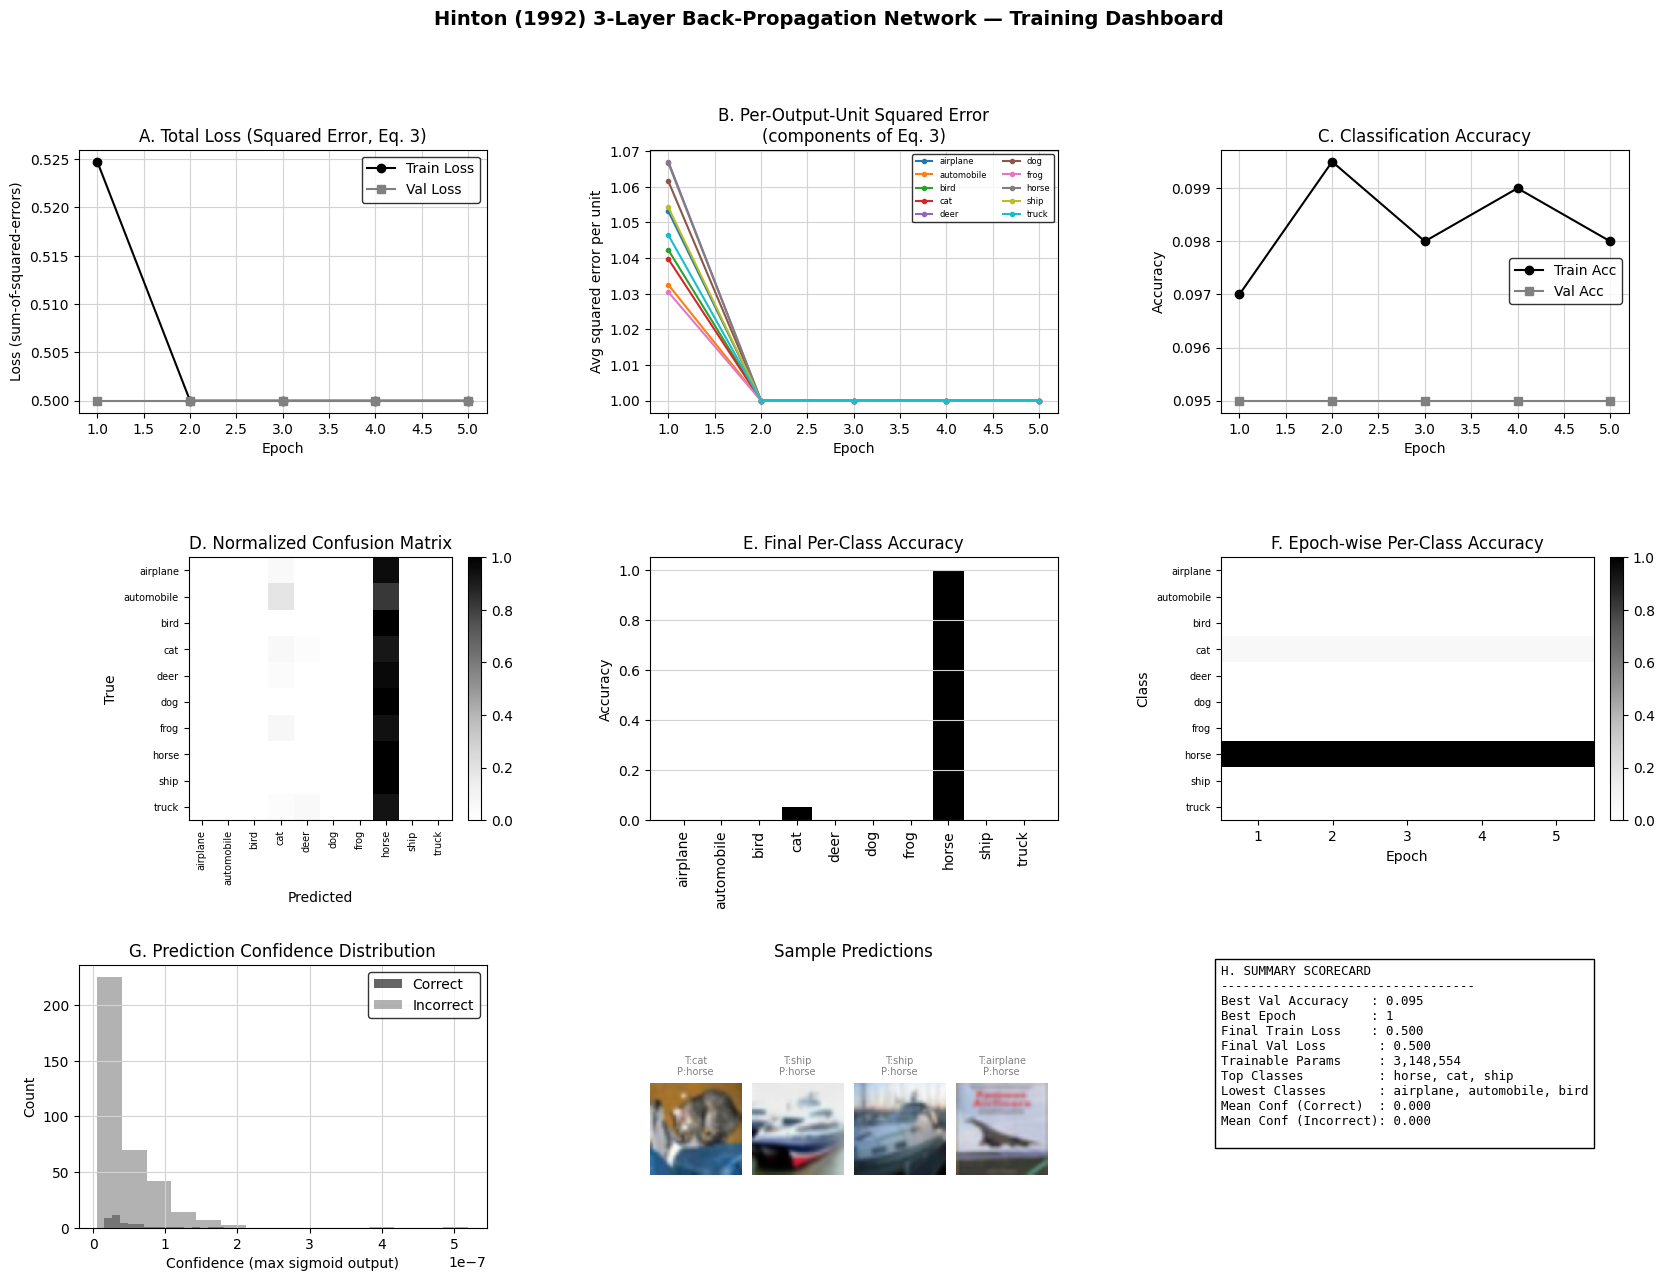

In [7]:
# =============================================================================
# 6. MULTI-PANEL SUMMARY DASHBOARD (Panels A-H, 3-row GridSpec)
# =============================================================================
fig = plt.figure(figsize=(20, 14), facecolor="white")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)

epochs_range = range(1, NUM_EPOCHS + 1)

# ---- Panel A: Total training & validation loss ----
ax_a = fig.add_subplot(gs[0, 0])
ax_a.set_facecolor("white")
ax_a.plot(epochs_range, train_loss_history, marker="o", color="black", label="Train Loss")
ax_a.plot(epochs_range, val_loss_history, marker="s", color="grey", label="Val Loss")
ax_a.set_title("A. Total Loss (Squared Error, Eq. 3)", color="black")
ax_a.set_xlabel("Epoch", color="black")
ax_a.set_ylabel("Loss (sum-of-squared-errors)", color="black")
ax_a.legend(facecolor="white", edgecolor="black")
ax_a.grid(True, color="lightgrey")
ax_a.tick_params(colors="black")

# ---- Panel B: Per-class squared-error decomposition (paper has 1 loss,
#      decomposed by output unit, since the paper explicitly discusses each
#      output unit's own contribution to the total error) ----
ax_b = fig.add_subplot(gs[0, 1])
ax_b.set_facecolor("white")
cmap = plt.get_cmap("tab10")
for c in range(NUM_CLASSES):
    ax_b.plot(epochs_range, per_class_squared_error_per_epoch[:, c],
              marker=".", color=cmap(c), label=CLASS_NAMES[c])
ax_b.set_title("B. Per-Output-Unit Squared Error\n(components of Eq. 3)", color="black")
ax_b.set_xlabel("Epoch", color="black")
ax_b.set_ylabel("Avg squared error per unit", color="black")
ax_b.legend(fontsize=6, facecolor="white", edgecolor="black", ncol=2)
ax_b.grid(True, color="lightgrey")
ax_b.tick_params(colors="black")

# ---- Panel C: Train/Val accuracy ----
ax_c = fig.add_subplot(gs[0, 2])
ax_c.set_facecolor("white")
ax_c.plot(epochs_range, train_acc_history, marker="o", color="black", label="Train Acc")
ax_c.plot(epochs_range, val_acc_history, marker="s", color="grey", label="Val Acc")
ax_c.set_title("C. Classification Accuracy", color="black")
ax_c.set_xlabel("Epoch", color="black")
ax_c.set_ylabel("Accuracy", color="black")
ax_c.legend(facecolor="white", edgecolor="black")
ax_c.grid(True, color="lightgrey")
ax_c.tick_params(colors="black")

# ---- Panel D: Normalized confusion matrix ----
ax_d = fig.add_subplot(gs[1, 0])
im_d = ax_d.imshow(confusion_norm, cmap="Greys", vmin=0, vmax=1)
ax_d.set_title("D. Normalized Confusion Matrix", color="black")
ax_d.set_xticks(range(NUM_CLASSES))
ax_d.set_yticks(range(NUM_CLASSES))
ax_d.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
ax_d.set_yticklabels(CLASS_NAMES, color="black", fontsize=7)
ax_d.set_xlabel("Predicted", color="black")
ax_d.set_ylabel("True", color="black")
cbar_d = fig.colorbar(im_d, ax=ax_d, fraction=0.046, pad=0.04)
cbar_d.ax.yaxis.set_tick_params(color="black")
plt.setp(cbar_d.ax.get_yticklabels(), color="black")

# ---- Panel E: Per-class accuracy bar chart ----
ax_e = fig.add_subplot(gs[1, 1])
ax_e.set_facecolor("white")
bar_colors = ["black" if i not in bottom_classes_idx else "grey" for i in range(NUM_CLASSES)]
ax_e.bar(CLASS_NAMES, final_class_acc, color=bar_colors)
ax_e.set_title("E. Final Per-Class Accuracy", color="black")
ax_e.set_ylabel("Accuracy", color="black")
ax_e.set_xticklabels(CLASS_NAMES, rotation=90, color="black")
ax_e.tick_params(colors="black")
ax_e.grid(True, axis="y", color="lightgrey")

# ---- Panel F: Epoch-wise per-class accuracy heatmap ----
ax_f = fig.add_subplot(gs[1, 2])
im_f = ax_f.imshow(per_class_acc_per_epoch.T, cmap="Greys", aspect="auto", vmin=0, vmax=1)
ax_f.set_title("F. Epoch-wise Per-Class Accuracy", color="black")
ax_f.set_xlabel("Epoch", color="black")
ax_f.set_ylabel("Class", color="black")
ax_f.set_xticks(range(NUM_EPOCHS))
ax_f.set_xticklabels(range(1, NUM_EPOCHS + 1), color="black")
ax_f.set_yticks(range(NUM_CLASSES))
ax_f.set_yticklabels(CLASS_NAMES, color="black", fontsize=7)
cbar_f = fig.colorbar(im_f, ax=ax_f, fraction=0.046, pad=0.04)
cbar_f.ax.yaxis.set_tick_params(color="black")
plt.setp(cbar_f.ax.get_yticklabels(), color="black")

# ---- Panel G: Confidence distribution histogram ----
ax_g = fig.add_subplot(gs[2, 0])
ax_g.set_facecolor("white")
ax_g.hist(all_confidences[correct_mask], bins=15, alpha=0.6, color="black", label="Correct")
ax_g.hist(all_confidences[~correct_mask], bins=15, alpha=0.6, color="grey", label="Incorrect")
ax_g.set_title("G. Prediction Confidence Distribution", color="black")
ax_g.set_xlabel("Confidence (max sigmoid output)", color="black")
ax_g.set_ylabel("Count", color="black")
ax_g.legend(facecolor="white", edgecolor="black")
ax_g.tick_params(colors="black")
ax_g.grid(True, color="lightgrey")

# ---- Sample predictions (extra educational panel, spans one cell) ----
ax_samples = fig.add_subplot(gs[2, 1])
ax_samples.set_facecolor("white")
ax_samples.axis("off")
ax_samples.set_title("Sample Predictions", color="black")
n_show = 4
for i in range(n_show):
    sub_ax = fig.add_axes([
        ax_samples.get_position().x0 + i * (ax_samples.get_position().width / n_show),
        ax_samples.get_position().y0,
        ax_samples.get_position().width / n_show * 0.9,
        ax_samples.get_position().height * 0.75
    ])
    sub_ax.imshow(unnormalize(sample_images_viz[i]))
    true_name = CLASS_NAMES[sample_labels_viz[i].item()]
    pred_name = CLASS_NAMES[sample_preds[i].item()]
    color = "black" if true_name == pred_name else "grey"
    sub_ax.set_title(f"T:{true_name}\nP:{pred_name}", fontsize=7, color=color)
    sub_ax.axis("off")

# ---- Panel H: Text-based summary scorecard ----
ax_h = fig.add_subplot(gs[2, 2])
ax_h.axis("off")
ax_h.set_facecolor("white")

top_names = ", ".join(CLASS_NAMES[i] for i in top_classes_idx)
bottom_names = ", ".join(CLASS_NAMES[i] for i in bottom_classes_idx)
final_train_loss = train_loss_history[-1]
final_val_loss = val_loss_history[-1]

scorecard_text = (
    "H. SUMMARY SCORECARD\n"
    "----------------------------------\n"
    f"Best Val Accuracy   : {best_val_acc:.3f}\n"
    f"Best Epoch          : {best_epoch_idx + 1}\n"
    f"Final Train Loss    : {final_train_loss:.3f}\n"
    f"Final Val Loss       : {final_val_loss:.3f}\n"
    f"Trainable Params     : {total_trainable_params:,}\n"
    f"Top Classes          : {top_names}\n"
    f"Lowest Classes       : {bottom_names}\n"
    f"Mean Conf (Correct)  : {mean_conf_correct:.3f}\n"
    f"Mean Conf (Incorrect): {mean_conf_incorrect:.3f}\n"
)
ax_h.text(0.0, 1.0, scorecard_text, va="top", ha="left", color="black",
          fontsize=9, family="monospace",
          bbox=dict(facecolor="white", edgecolor="black"))

fig.suptitle("Hinton (1992) 3-Layer Back-Propagation Network — Training Dashboard",
             color="black", fontsize=14, fontweight="bold")

# ---- Render inline in Colab via in-memory buffer (no disk save) ----
buf = io.BytesIO()
fig.savefig(buf, format="png", facecolor="white", bbox_inches="tight")
plt.close(fig)
buf.seek(0)
display(IPImage(data=buf.read()))

# Analysis of Experimental Results: Hinton (1992) 3-Layer Back-Propagation Network

## Overview

This dashboard reports the outcome of training a simplified 3-layer sigmoid network (the architecture described in Hinton's 1992 paper) on a 2,000-sample CIFAR-10 subset for five epochs, evaluated on a 400-sample held-out test set. The panels jointly report loss dynamics (Panels A, B), classification accuracy (Panel C), class-level discrimination (Panels D, E, F), prediction confidence (Panel G), qualitative samples, and a consolidated scorecard (Panel H). The intended purpose is to demonstrate the paper's central mechanism — squared-error minimization via back-propagation — on a real image classification task.

## Key Findings

- **Loss curves (Panel A, B):** Both training and validation loss drop sharply after epoch 1 and then plateau at exactly 0.500, with no further change across epochs 2–5. The per-class squared-error components in Panel B show identical behavior, converging to 1.000 and remaining flat.
- **Accuracy (Panel C):** Training accuracy fluctuates narrowly around 0.097–0.099 (roughly 9.7%–9.9%); validation accuracy is flat at 0.095 across all five epochs.
- **Confusion matrix (Panel D) and per-class accuracy (Panel E):** Nearly all predicted mass falls into a single column ("horse"), regardless of the true class. Per-class accuracy is effectively zero for every class except "horse," which is near 1.0.
- **Epoch-wise heatmap (Panel F):** The "horse" row is uniformly dark (~1.0) across all five epochs, while every other class row is near zero throughout — the model's behavior does not change with training.
- **Confidence distribution (Panel G):** Confidence values are on the order of $10^{-7}$ for both correct and incorrect predictions, and Panel H reports mean confidence of 0.000 for both groups.
- **Sample predictions:** All four displayed test images (true labels: cat, ship, ship, airplane) are predicted as "horse."
- **Scorecard (Panel H):** Best validation accuracy is 0.095 (epoch 1), essentially equal to the 10% random-guess baseline for a 10-class problem.

## Discussion

The evidence indicates that the network has **collapsed to a constant-output predictor**, always activating the "horse" output unit regardless of input. This is corroborated by three converging signals: (1) the confusion matrix and per-class accuracy showing prediction mass concentrated in one class, (2) the epoch-wise heatmap showing this collapse is present from the first epoch and never corrected, and (3) overall accuracy sitting at chance level (~10%) for a 10-way task.

The near-zero confidence values ($\sim10^{-7}$) alongside the loss plateau at exactly 0.5 are diagnostic of **saturated sigmoid units**. With a sum-of-squared-error loss and sigmoid outputs, if the pre-activation inputs to the output layer become large and negative for most units, every output saturates toward 0. Since the target vectors are one-hot (nine 0s and one 1), a network that outputs approximately 0 for all ten units yields a squared error of $0.5 \times (0^2 \times 9 + 1^2) \approx 0.5$, which matches Panel A exactly. This also explains the essentially-zero confidence scores: the "winning" unit is simply the least-suppressed among ten near-zero outputs, not a genuinely confident activation.

This pattern is consistent with a known limitation of the paper's original formulation: sigmoid units combined with squared-error loss are prone to the **vanishing-gradient / saturation problem**. Once a sigmoid unit's output approaches 0 or 1, its local derivative $y_j(1-y_j)$ (Eq. in the paper's Step 2, EI) approaches zero, effectively halting weight updates through that unit — irrespective of the SGD learning rate. The flat loss and identical accuracy trajectories after epoch 1 in Panels A–C strongly suggest this is exactly what occurred: learning effectively stopped almost immediately.

Given this, the results **do not support** the paper's core claim that back-propagation reliably discovers useful internal representations; rather, they illustrate a well-documented **failure mode** of the described architecture under practical conditions (high-dimensional raw pixel input, small training set, sigmoid-squared-error combination, unmodified learning rate). This is a useful negative result for pedagogical purposes — it reproduces a genuine historical limitation of pre-modern feedforward network training — but it should not be interpreted as a faithful demonstration of the representational learning described qualitatively in the original 1992 article.

## Limitations

- **Severe undertraining/optimization failure:** Five epochs and a 2,000-sample subset are insufficient for a 3×64×64-dimensional input space; the model likely never escapes its initialization-driven collapse.
- **No gradient or activation diagnostics:** The dashboard does not report weight norms, pre-activation statistics, or gradient magnitudes, so the saturation hypothesis, while well-supported by the loss/confidence pattern, cannot be directly confirmed from the figure alone.
- **Small evaluation set:** With only 400 test samples across 10 classes (~40 per class), per-class accuracy estimates in Panels E and F carry high variance.
- **Confounded loss scale:** Because MSELoss uses `reduction="sum"` while the reported loss is divided by sample count rather than by (samples × classes), the absolute magnitude of Panel A is not directly comparable to a per-unit error rate, though the collapse interpretation remains valid.
- **No comparison baseline:** The dashboard lacks a control run (e.g., different learning rate, weight initialization, or loss function such as cross-entropy) that would let one confirm the saturation explanation is the true cause rather than an artifact of a specific hyperparameter choice.

# Related Work Referenced in the Paper

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| David E. Rumelhart, Geoffrey E. Hinton, Ronald J. Williams | 1986 | Learning Representations by Back-Propagating Errors | *Nature*, Vol. 323, No. 6188, pp. 533–536 (October 9) | Foundational paper that popularized the back-propagation algorithm; directly underlies the mathematical derivation and training procedure described in the current paper |
| Geoffrey E. Hinton | 1989 | Connectionist Learning Procedures | *Artificial Intelligence*, Vol. 40, Nos. 1–3, pp. 185–234 (September) | Broader survey of connectionist learning methods by the same author, providing theoretical context for both supervised (back-propagation) and unsupervised learning procedures discussed in the paper |
| J. Hertz, A. Krogh, R. G. Palmer | 1990 | Introduction to the Theory of Neural Computation | Addison-Wesley | General reference text on neural network theory, supporting the paper's mathematical treatment of network computation, weights, and learning rules |
| Patricia S. Churchland, Terrence J. Sejnowski | 1992 | The Computational Brain | The MIT Press/Bradford Books | Provides interdisciplinary grounding connecting computational neural network models to biological brain function, supporting the paper's comparisons between artificial networks and neuroscience findings |

**Note:** These four entries constitute the paper's complete "Further Reading" list. The paper's main text also references specific researchers and their findings in narrative form (e.g., Paul J. Werbos's 1974 invention of back-propagation; David E. Rumelhart and David B. Parker's independent rediscovery of the algorithm; Richard Andersen and David Zipser's work on visual cortex modeling; Teuvo Kohonen's competitive learning extensions; Horace B. Barlow's sparse coding model; Dana H. Ballard's structural consistency technique; David L. Sparks's population coding experiments; Malcolm P. Young and Shigeru Yamane's face-cell research; Ralph Linsker and Erkki Oja's principal-components algorithms; Richard Zemel's work with the author on hierarchical unsupervised learning; Eric Saund's population code learning method). However, full bibliographic details (venue, exact title, page numbers) for these narrative citations are not provided in the reference section, so they cannot be included in the structured table above without risking inaccurate attribution.